
# Telecom Churn Prediction

Este notebook apresenta o desenvolvimento do projeto Telecom Churn Prediction, voltado à análise de dados de clientes de telecomunicações e à previsão de cancelamento de serviços (Customer Churn).

O projeto contempla análise exploratória, preparação dos dados, treinamento, avaliação e comparação de modelos de classificação, utilizando Python e técnicas de Machine Learning.
  

### Verificação da conexão com Google Colab

Antes da configuração do ambiente, foi realizado um teste para verificar se o notebook estava executando no servidor remoto do Google Colab, e não no ambiente Python local.

A verificação identifica o executável Python, o sistema operacional e a presença de uma variável de ambiente característica do Google Colab.

In [ ]:
import sys
import os

print("Python:", sys.executable)
print("Sistema:", os.name)
print("Ambiente Colab:", "COLAB_RELEASE_TAG" in os.environ)

Python: /usr/bin/python3
Sistema: posix
Ambiente Colab: True


### Identificação e configuração do ambiente Python

Esta etapa identifica as características do ambiente de execução, incluindo a versão do Python, o sistema operacional e o diretório de trabalho.

Essas informações auxiliam na reprodutibilidade dos experimentos e na identificação de diferenças entre a execução local e o ambiente remoto do Google Colab.

A definição dos caminhos do projeto será realizada separadamente, considerando que os arquivos locais do VS Code não estão automaticamente disponíveis no servidor remoto.

In [2]:
# Identificação do ambiente de execução

import sys
import platform
from pathlib import Path

# Informações do ambiente
VERSAO_PYTHON = platform.python_version()
SISTEMA_OPERACIONAL = platform.system()
EXECUTAVEL_PYTHON = sys.executable
DIRETORIO_ATUAL = Path.cwd()

# Exibição das informações
print(f"Versão do Python: {VERSAO_PYTHON}")
print(f"Sistema operacional: {SISTEMA_OPERACIONAL}")
print(f"Executável Python: {EXECUTAVEL_PYTHON}")
print(f"Diretório de trabalho: {DIRETORIO_ATUAL}")

Versão do Python: 3.11.5
Sistema operacional: Windows
Executável Python: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\.venv\Scripts\python.exe
Diretório de trabalho: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\notebooks


In [6]:
# ============================================================
# CONFIGURAÇÃO DOS CAMINHOS E IMPORTAÇÃO DOS MÓDULOS DO PROJETO
# ============================================================

from pathlib import Path
import sys

# Raiz do projeto (um nível acima da pasta notebooks)
RAIZ_PROJETO = Path.cwd().parent

# Adiciona a raiz ao caminho de importação
if str(RAIZ_PROJETO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROJETO))

# Importa a função de carregamento do dataset
from src.data.dataset import carregar_dataset

print("Configuração do projeto concluída com sucesso!")

Configuração do projeto concluída com sucesso!


## Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para a análise exploratória de dados (EDA).

- **Pandas:** manipulação, inspeção e análise de dados tabulares.
- **NumPy:** operações numéricas e estatísticas.
- **Matplotlib:** criação e personalização de gráficos.
- **Seaborn:** visualizações estatísticas, distribuições e correlações.


In [3]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Verificação das versões
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

print("\nBibliotecas importadas com sucesso!")

Pandas: 3.0.6
NumPy: 2.4.6
Matplotlib: 3.11.2
Seaborn: 0.13.2

Bibliotecas importadas com sucesso!


## Fase 1 — Análise Exploratória de Dados (EDA)

A Análise Exploratória de Dados (EDA) tem como objetivo compreender a estrutura, a distribuição e as características do conjunto de dados antes da construção dos modelos preditivos.

Nesta etapa, serão realizadas:

1. Inspeção das dimensões e dos tipos de dados.
2. Análise estatística descritiva das variáveis.
3. Verificação de valores ausentes e registros duplicados.
4. Visualização da distribuição das variáveis preditoras.
5. Análise da proporção das classes da variável-alvo (Churn).
6. Investigação das correlações entre variáveis numéricas utilizando o coeficiente de Pearson.
7. Interpretação dos resultados e identificação de possíveis necessidades de pré-processamento.

Os resultados obtidos orientarão as decisões técnicas das próximas etapas do pipeline de Machine Learning.

In [7]:
from pathlib import Path

print("Pasta atual:", Path.cwd())
print("Pasta src disponível:", Path("src").exists())

Pasta atual: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\notebooks
Pasta src disponível: False


### 1.1 — Carregamento do Dataset

Nesta etapa, será carregado o arquivo `dataset_telecom.csv`, utilizando a função `carregar_dataset()` definida no módulo `src/data/dataset.py`.

Em seguida, serão verificadas as dimensões e as primeiras observações do conjunto de dados.

In [10]:
# ============================================================
# 1.1 — CARREGAMENTO DO DATASET
# ============================================================

CAMINHO_DATASET = RAIZ_PROJETO / "data" / "raw" / "dataset_telecom.csv"

df = carregar_dataset(CAMINHO_DATASET)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

display(df.head())

Linhas: 7068
Colunas: 21


,id_cliente,genero,idoso,tem_parceiro,tem_dependentes,meses_contrato,servico_telefone,linhas_multiplas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,valor_total,cancelou
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


#### Observações

O dataset foi carregado com sucesso, apresentando **7.068 registros e 21 variáveis**.

A visualização inicial das cinco primeiras observações permite conhecer a organização dos dados e confirmar o carregamento das informações.

### 1.2 — Estrutura e Tipos de Dados

Nesta etapa, será examinada a estrutura do dataset, identificando os nomes das variáveis, seus tipos de dados e a quantidade de valores não nulos.

Essa análise permitirá reconhecer variáveis numéricas e categóricas, além de identificar possíveis problemas que deverão ser considerados nas próximas etapas.

In [11]:
# ============================================================
# 1.2 — ESTRUTURA E TIPOS DE DADOS
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7068 entries, 0 to 7067
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7068 non-null   str    
 1   genero                7068 non-null   str    
 2   idoso                 7068 non-null   int64  
 3   tem_parceiro          7068 non-null   str    
 4   tem_dependentes       7068 non-null   str    
 5   meses_contrato        6784 non-null   float64
 6   servico_telefone      7068 non-null   str    
 7   linhas_multiplas      7068 non-null   str    
 8   servico_internet      7068 non-null   str    
 9   seguranca_online      7068 non-null   str    
 10  backup_online         7068 non-null   str    
 11  protecao_dispositivo  7068 non-null   str    
 12  suporte_tecnico       7068 non-null   str    
 13  streaming_tv          7068 non-null   str    
 14  streaming_filmes      7068 non-null   str    
 15  tipo_contrato         7068 non-n

#### Observações

O dataset apresenta **16 variáveis do tipo `str`, 3 do tipo `float64` e 2 do tipo `int64`**, reunindo informações cadastrais, contratuais e financeiras.

Foram identificados valores ausentes em três variáveis:

- `meses_contrato`: 284 registros (4,02%);
- `valor_mensal`: 354 registros (5,01%);
- `valor_total`: 11 registros (0,16%).

A variável-alvo `cancelou` não apresenta valores ausentes. As variáveis `idoso` e `cancelou`, embora armazenadas como inteiros, deverão ser consideradas conforme sua natureza categórica.

Os valores ausentes serão investigados na etapa de qualidade dos dados, antes de qualquer decisão de tratamento.

### 1.3 — Análise Estatística Descritiva

Nesta etapa, serão analisadas as principais estatísticas descritivas das variáveis numéricas do dataset, utilizando o método `describe()` da biblioteca Pandas.

Serão observados:

- **Count:** quantidade de valores não nulos.
- **Mean:** média aritmética.
- **Std:** desvio-padrão, que indica a dispersão dos valores.
- **Min e Max:** valores mínimo e máximo.
- **25%, 50% e 75%:** quartis da distribuição, sendo 50% a mediana.

Essa análise permitirá compreender a distribuição das variáveis, identificar possíveis valores extremos e reconhecer características relevantes para a futura construção do modelo preditivo.

In [13]:
# ============================================================
# 1.3 — ANÁLISE ESTATÍSTICA DESCRITIVA
# ============================================================

# Estatísticas descritivas das variáveis numéricas
estatisticas_numericas = df.describe()

# Exibição dos resultados com duas casas decimais
display(estatisticas_numericas.round(2))

,idoso,meses_contrato,valor_mensal,valor_total,cancelou
count,7068.00,6784.00,6714.00,7057.00,7068.00
mean,0.16,32.36,65.87,2283.28,0.26
std,0.37,24.56,40.99,2265.86,0.44
min,0.00,0.00,18.25,18.80,0.00
25%,0.00,9.00,35.65,401.95,0.00
50%,0.00,29.00,70.35,1398.60,0.00
75%,0.00,55.00,89.95,3791.60,1.00
max,1.00,72.00,921.40,8684.80,1.00


#### Observações

A análise descritiva revelou um possível valor atípico em `valor_mensal`, cujo máximo (921,40) está consideravelmente acima do terceiro quartil (89,95).

Também foram observados indícios de desbalanceamento na variável-alvo `cancelou`, com média de aproximadamente 0,265, considerando a codificação binária (0 e 1).

Esses aspectos serão investigados nas próximas etapas da análise exploratória.

### 1.4 — Distribuição do Tempo de Contrato

Nesta etapa, será analisada a distribuição da variável `meses_contrato`, que representa o tempo de relacionamento dos clientes com a empresa.

Será utilizado um histograma para identificar a concentração dos registros, a dispersão dos valores e possíveis padrões de permanência.

A visualização permitirá investigar características relevantes para a futura previsão de cancelamento (*churn*).

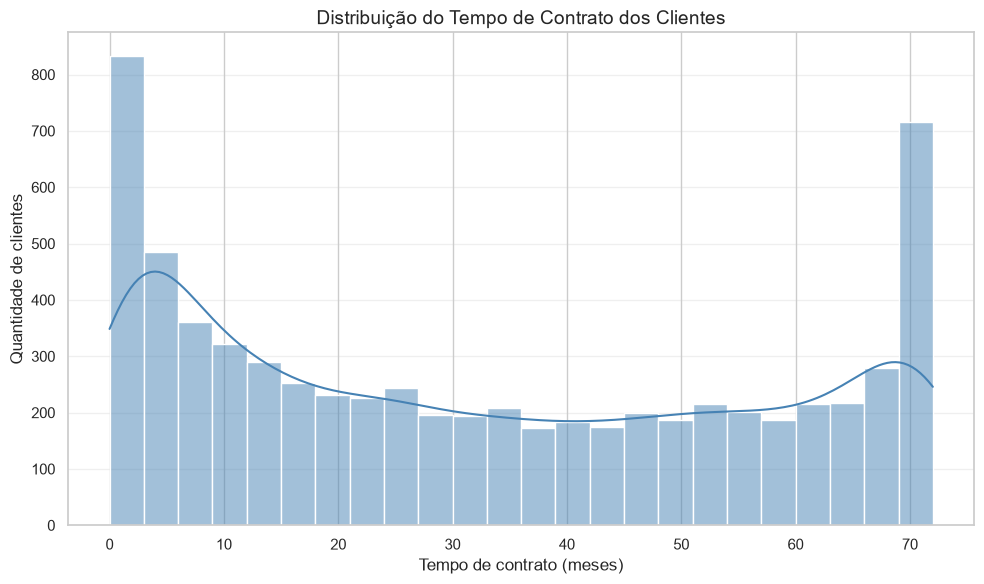

Gráfico salvo em: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\01_distribuicao_tempo_contrato.png


In [14]:
# ============================================================
# 1.4 — DISTRIBUIÇÃO DO TEMPO DE CONTRATO
# ============================================================

# Diretório de saída dos gráficos
DIRETORIO_FIGURAS = RAIZ_PROJETO / "outputs" / "figures"
DIRETORIO_FIGURAS.mkdir(parents=True, exist_ok=True)

# Construção do histograma
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="meses_contrato",
    bins=24,
    kde=True,
    color="steelblue",
    ax=ax
)

# Configuração da visualização
ax.set_title("Distribuição do Tempo de Contrato dos Clientes", fontsize=14)
ax.set_xlabel("Tempo de contrato (meses)")
ax.set_ylabel("Quantidade de clientes")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Salvamento automático do gráfico
CAMINHO_GRAFICO = DIRETORIO_FIGURAS / "01_distribuicao_tempo_contrato.png"

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

# Exibição no notebook
plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A distribuição do tempo de contrato apresenta concentrações mais elevadas entre clientes com poucos meses de relacionamento e aqueles próximos de 72 meses.

Esse comportamento sugere a presença de dois perfis distintos: clientes recentes e clientes com longo histórico de permanência.

A variável `meses_contrato` poderá ser relevante para a previsão de churn. Entretanto, será necessário comparar sua distribuição entre clientes que cancelaram e aqueles que permaneceram para verificar essa relação.

### 1.5 — Distribuição da Variável-Alvo (Churn)

Nesta etapa, será analisada a distribuição da variável-alvo `cancelou`, utilizando um gráfico de barras para comparar a quantidade de clientes que permaneceram e daqueles que cancelaram o serviço.

Também serão calculadas as frequências absolutas e relativas de cada classe, permitindo avaliar o possível desbalanceamento dos dados e suas implicações para o treinamento do modelo.

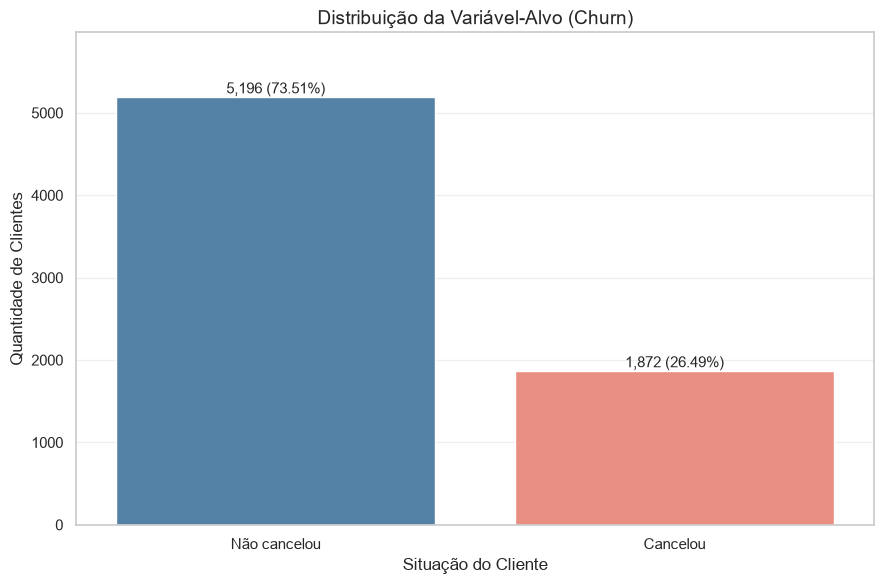

Gráfico salvo em: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\02_distribuicao_churn.png


In [15]:
# ============================================================
# 1.5 — DISTRIBUIÇÃO DA VARIÁVEL-ALVO (CHURN)
# ============================================================

# Frequências absolutas e percentuais
contagem_churn = df["cancelou"].value_counts().sort_index()
percentual_churn = df["cancelou"].value_counts(normalize=True).sort_index() * 100

# Construção do gráfico
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    x=["Não cancelou", "Cancelou"],
    y=contagem_churn.values,
    hue=["Não cancelou", "Cancelou"],
    palette=["steelblue", "salmon"],
    legend=False,
    ax=ax
)

# Exibição das quantidades e percentuais
for i, (quantidade, percentual) in enumerate(
    zip(contagem_churn.values, percentual_churn.values)
):
    ax.text(
        i,
        quantidade + 40,
        f"{quantidade:,} ({percentual:.2f}%)",
        ha="center",
        fontsize=11
    )

# Configuração da visualização
ax.set_title("Distribuição da Variável-Alvo (Churn)", fontsize=14)
ax.set_xlabel("Situação do Cliente")
ax.set_ylabel("Quantidade de Clientes")
ax.set_ylim(0, contagem_churn.max() * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Salvamento automático
CAMINHO_GRAFICO = DIRETORIO_FIGURAS / "02_distribuicao_churn.png"

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A variável-alvo `cancelou` apresenta uma distribuição desbalanceada, com **73,51% dos clientes permanecendo ativos** e **26,49% registrando cancelamento**.

A classe majoritária possui aproximadamente 2,8 vezes mais registros que a classe minoritária.

Esse desbalanceamento deverá ser considerado na modelagem, especialmente na escolha das métricas de avaliação, como precisão, recall e F1-score, pois a acurácia isolada pode produzir uma avaliação inadequada do desempenho preditivo.

### 1.6 — Análise de Correlação de Pearson

Nesta etapa, será utilizada a correlação de Pearson para investigar a intensidade e a direção das relações lineares entre as variáveis numéricas do dataset.

Os coeficientes variam de -1 a +1, sendo valores próximos de zero indicativos de ausência de correlação linear relevante.

O mapa de calor permitirá identificar associações entre as variáveis e possíveis relações com a variável-alvo `cancelou`, contribuindo para a análise das características preditoras.

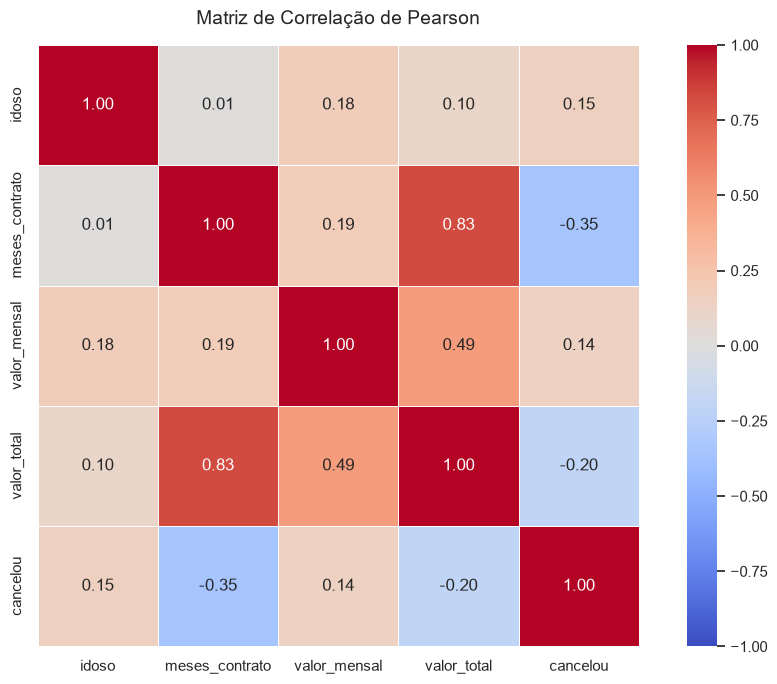

Gráfico salvo em: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\telecom-churn-prediction\outputs\figures\03_correlacao_pearson.png


In [16]:
# ============================================================
# 1.6 — ANÁLISE DE CORRELAÇÃO DE PEARSON
# ============================================================

# Seleção das variáveis numéricas
dados_numericos = df.select_dtypes(include="number")

# Cálculo da matriz de correlação
matriz_correlacao = dados_numericos.corr(method="pearson")

# Construção do mapa de calor
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title(
    "Matriz de Correlação de Pearson",
    fontsize=14,
    pad=15
)

plt.tight_layout()

# Salvamento automático
CAMINHO_GRAFICO = DIRETORIO_FIGURAS / "03_correlacao_pearson.png"

fig.savefig(
    CAMINHO_GRAFICO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico salvo em: {CAMINHO_GRAFICO}")

#### Observações

A matriz de correlação de Pearson revelou as seguintes relações:

- **`meses_contrato` × `cancelou` (-0,35):** correlação negativa moderada, indicando que clientes com maior tempo de contrato tendem a apresentar menor frequência de cancelamento.
- **`valor_total` × `cancelou` (-0,20):** correlação negativa fraca, sugerindo uma associação entre maior valor acumulado e menor ocorrência de churn.
- **`valor_mensal` × `cancelou` (0,14):** correlação positiva fraca, indicando uma possível associação entre mensalidades mais elevadas e cancelamento.
- **`idoso` × `cancelou` (0,15):** correlação positiva fraca, sugerindo maior ocorrência de cancelamento entre clientes classificados como idosos.
- **`meses_contrato` × `valor_total` (0,83):** correlação positiva forte, indicando elevada associação entre o tempo de contrato e o valor total acumulado.

A correlação entre `meses_contrato` e `valor_total` merece atenção durante a modelagem, especialmente em algoritmos sensíveis à multicolinearidade.

Os resultados indicam que o tempo de contrato pode ser uma variável preditora relevante para o churn. Entretanto, **correlação não implica causalidade**, e essas associações deverão ser avaliadas em conjunto com as demais variáveis do dataset.

### 1.7 — Conclusão da Análise Exploratória

A análise exploratória dos **7.068 registros e 21 variáveis** identificou padrões relevantes para a previsão de cancelamento de clientes (*churn*).

Observou-se um **desbalanceamento da variável-alvo**, com 26,49% de cancelamentos, além de uma associação negativa entre o tempo de contrato e o churn (-0,35), indicando menor frequência de cancelamento entre clientes com maior tempo de relacionamento.

Também foram identificados valores ausentes, possíveis valores atípicos e uma correlação elevada entre `meses_contrato` e `valor_total` (0,83).

**Esses resultados evidenciam características importantes do dataset e fornecem subsídios para a definição de uma estratégia de modelagem consistente**, considerando a qualidade dos dados, o desbalanceamento das classes e a relevância das variáveis preditoras.